<div align="center">

**UNIVERSIDAD DISTRITAL FRANCISCO JOSÉ DE CALDAS**<br>
Facultad de Ingeniería · Ingeniería de Sistemas

# Notas de Clase: Comparación de clasificadores y validación cruzada

### Minería de Datos · 26150 · Bloque 3 — Modelos de clasificación

Docente: **Jhon Alejandro Varón Robayo**<br>
Sábado 19 de septiembre de 2026 · Sala de Informática 601 · periodo 2026-3

</div>

---

# Introducción

Ayer cerramos el bloque con SVM y la tabla comparativa dejó algo incómodo: **KNN escalado y SVM
lineal escalado dieron exactamente lo mismo** —60 de 64 malignos detectados, una sola falsa alarma—.
Y la pregunta quedó abierta:

> Si dos modelos dan casi lo mismo, **¿cuál gana?** Y sobre todo: **¿quién dijo que ese número es el
> número?**

Todo lo que hemos medido hasta hoy salió de **una sola partición** entre entrenamiento y prueba. Hoy
vamos a ver que esa partición, por sí sola, **puede coronar a cuatro ganadores distintos con los
mismos datos y los mismos modelos**. Y vamos a armar la tabla que se entrega el **miércoles 23**.

**Datos reales:** los mismos 569 tumores de mama del estudio de diagnóstico de Wisconsin
(`load_breast_cancer`, incluido en scikit-learn). No hay que subir ningún archivo y así comparamos
contra lo de ayer.

**La sesión es de manos a la obra.** La segunda mitad es de ustedes: cada grupo reemplaza el dataset
por el suyo y sale de aquí con la tabla de la entrega armada.

# Objetivos de aprendizaje

Al terminar la sesión, cada estudiante debe poder:

1. Mostrar con números por qué **una sola partición engaña**, y por qué un ranking construido sobre
   ella no se sostiene.
2. Ejecutar y leer una **validación cruzada k-fold estratificada**: la media como estimación y la
   **dispersión como la confianza** que le tengo a esa estimación.
3. Comparar varios modelos **con y sin escalar** dentro de un `Pipeline`, entendiendo por qué el
   `Pipeline` es lo que evita que el escalado filtre información del conjunto de prueba.
4. Escoger hiperparámetros con **`GridSearchCV`** sin gastar el conjunto de prueba, y aplicar la regla
   de que **la prueba se toca una sola vez**.
5. **Decidir un ganador** —o declarar que no lo hay— con una regla escrita antes de mirar la tabla.
6. Armar la tabla de la **entrega del miércoles 23** sobre el dataset de su grupo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_validate, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

datos = load_breast_cancer()
X = pd.DataFrame(datos.data, columns=datos.feature_names)
y = pd.Series((datos.target == 0).astype(int))      # 1 = maligno

print("tumores:", len(y), "| malignos:", y.sum(), f"({y.mean():.1%})")
print("variables:", X.shape[1])

tumores: 569 | malignos: 212 (37.3%)
variables: 30


# 1. Una sola partición engaña

La clase positiva sigue siendo **maligno**, y el error caro sigue siendo el **falso negativo**: un
cáncer que no se detecta. La medida que manda, entonces, es el **recall**.

Vamos a hacer siempre lo mismo —partir 70/30, entrenar los cuatro modelos, medir el recall— pero
**cambiando la semilla** de la partición diez veces. Los datos no cambian. Los modelos no cambian.
Lo único que cambia es **a quién le tocó quedar en prueba**.

In [2]:
modelos = {"Árbol (prof. 4)":  DecisionTreeClassifier(max_depth=4, random_state=7),
           "KNN (k=5)":        KNeighborsClassifier(),
           "Naive Bayes":      GaussianNB(),
           "SVM lineal (C=1)": SVC(kernel="linear")}

filas = []
for semilla in range(1, 11):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.3,
                                          random_state=semilla, stratify=y)
    fila = {"semilla": semilla}
    for nombre, m in modelos.items():
        pipe = Pipeline([("escalador", StandardScaler()), ("modelo", m)])
        fila[nombre] = round(recall_score(yte, pipe.fit(Xtr, ytr).predict(Xte)), 3)
    filas.append(fila)

tabla1 = pd.DataFrame(filas).set_index("semilla")
tabla1["el mejor"] = [" y ".join(r[r == r.max()].index) for _, r in tabla1.iterrows()]
print(tabla1.to_string())

         Árbol (prof. 4)  KNN (k=5)  Naive Bayes  SVM lineal (C=1)                                        el mejor
semilla                                                                                                           
1                  0.859      0.906        0.844             0.906                    KNN (k=5) y SVM lineal (C=1)
2                  0.859      0.875        0.828             0.922                                SVM lineal (C=1)
3                  0.812      0.953        0.922             0.938                                       KNN (k=5)
4                  0.891      0.891        0.875             0.891  Árbol (prof. 4) y KNN (k=5) y SVM lineal (C=1)
5                  0.844      0.859        0.844             0.922                                SVM lineal (C=1)
6                  0.938      0.906        0.906             0.953                                SVM lineal (C=1)
7                  0.875      0.938        0.891             0.938              

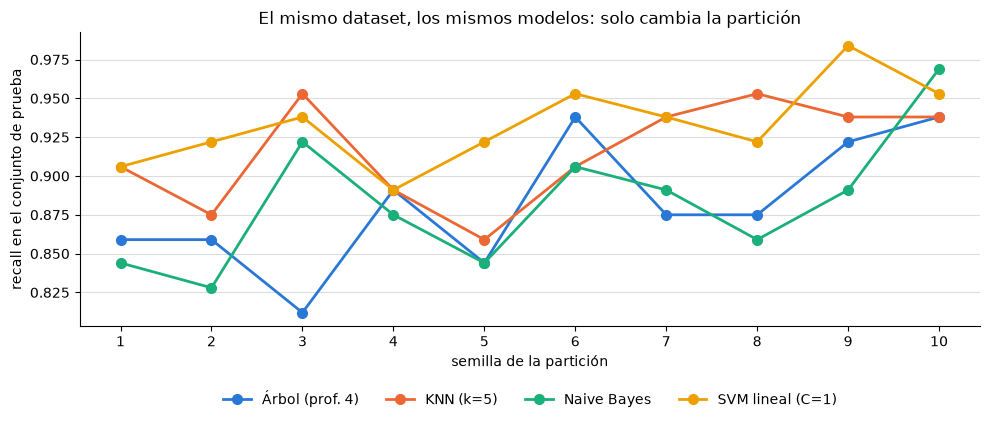

In [3]:
colores = {"Árbol (prof. 4)": "#2a78d6", "KNN (k=5)": "#eb6834",
           "Naive Bayes": "#1baf7a", "SVM lineal (C=1)": "#eda100"}

fig, ax = plt.subplots(figsize=(10, 4.5))
for nombre in modelos:
    ax.plot(tabla1.index, tabla1[nombre], marker="o", markersize=7, linewidth=2,
            color=colores[nombre], label=nombre)
ax.set_xlabel("semilla de la partición")
ax.set_ylabel("recall en el conjunto de prueba")
ax.set_title("El mismo dataset, los mismos modelos: solo cambia la partición")
ax.set_xticks(tabla1.index)
ax.grid(axis="y", color="#dddddd", linewidth=.8)
ax.set_axisbelow(True)
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, ncol=4, loc="lower center", bbox_to_anchor=(.5, -.32))
plt.tight_layout(); plt.show()

### Cómo se lee

| | Lo que dice |
|---|---|
| **Qué veo** | En diez particiones aparecen **los cuatro modelos** en el primer puesto: el SVM queda o empata de primero siete veces, el KNN cinco, el **árbol** alcanza el primer lugar en la semilla 4 (empatado a tres) y **Naive Bayes gana solo** en la semilla 10. El SVM va de 0,891 con la semilla 4 a 0,984 con la semilla 9. |
| **Qué significa** | Esos 9 puntos de diferencia son **57 de 64 malignos detectados contra 63 de 64** — seis tumores— y no los produjo un cambio de modelo, los produjo el azar de la partición. Un ranking armado sobre una sola semilla es un ranking sobre el azar. |
| **Qué decido** | **No reporto una métrica de una sola partición.** Repito la medición sobre varias particiones y reporto la media con su dispersión. Eso es la validación cruzada. |

> **Diferencia no es separación.** Que un modelo quede arriba en una tabla no significa que sea mejor:
> hay que preguntar primero cuánto se mueve esa tabla sola.

# 2. Validación cruzada k-fold estratificada

En vez de partir una vez, se parte el dataset en **k pedazos (folds)**. Se entrena con k−1 y se mide
en el que queda, y se rota, hasta que **cada fila haya estado exactamente una vez en prueba**.

**Estratificada** quiere decir que cada fold conserva la proporción de malignos del total. Sin eso, con
una clase minoritaria, puede tocar un fold con muy pocos positivos y la métrica se vuelve ruido.

Usamos **k = 5**: cinco mediciones, suficiente para ver la dispersión, y rápido en Colab.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

for i, (idx_tr, idx_te) in enumerate(cv.split(X, y), start=1):
    print(f"fold {i}: entrena con {len(idx_tr)} | mide en {len(idx_te)}"
          f" | malignos en prueba {y.iloc[idx_te].sum()} ({y.iloc[idx_te].mean():.1%})")

fold 1: entrena con 455 | mide en 114 | malignos en prueba 43 (37.7%)
fold 2: entrena con 455 | mide en 114 | malignos en prueba 43 (37.7%)
fold 3: entrena con 455 | mide en 114 | malignos en prueba 42 (36.8%)
fold 4: entrena con 455 | mide en 114 | malignos en prueba 42 (36.8%)
fold 5: entrena con 456 | mide en 113 | malignos en prueba 42 (37.2%)


In [5]:
print("recall por fold\n")
for nombre, m in modelos.items():
    pipe = Pipeline([("escalador", StandardScaler()), ("modelo", m)])
    s = cross_val_score(pipe, X, y, cv=cv, scoring="recall")
    print(f"{nombre:<18} {np.round(s, 3)}   media {s.mean():.3f}   desv. {s.std():.3f}")

recall por fold

Árbol (prof. 4)    [0.907 0.907 0.857 0.786 0.952]   media 0.882   desv. 0.057


KNN (k=5)          [0.953 0.977 0.857 0.881 0.976]   media 0.929   desv. 0.050
Naive Bayes        [0.907 0.977 0.833 0.833 0.952]   media 0.901   desv. 0.059
SVM lineal (C=1)   [0.907 0.977 0.952 0.929 1.   ]   media 0.953   desv. 0.033


### Cómo se lee

| | Lo que dice |
|---|---|
| **Qué veo** | El KNN escalado va de 0,857 a 0,977 entre folds: media 0,929 con desviación 0,050. El SVM se mueve menos: media 0,953 con desviación 0,033. El árbol es el más bajo y el más inestable junto con Naive Bayes (desviación 0,057 y 0,059). |
| **Qué significa** | La media es la estimación; **la desviación es cuánta confianza le tengo a esa estimación**. Un 0,929 ± 0,050 quiere decir «si repito esto con otros datos parecidos, espero algo entre 0,88 y 0,98». Eso no es un número, es un rango. |
| **Qué decido** | Reporto **media ± desviación**, nunca la media sola. Y antes de decir que un modelo le gana a otro, miro si los rangos se traslapan. |

> Comparados **fold a fold** —los mismos cinco cortes para los dos— el SVM le gana al KNN en 3 folds,
> empata en 1 y pierde en 1. No es un barrido: es una ventaja pequeña y repetida.

# 3. La tabla de la entrega: con y sin escalar, todo dentro de un `Pipeline`

## 3.1 Por qué `Pipeline` y no escalar antes

Si escalamos **todo el dataset** antes de partir, la media y la desviación con las que escalamos
**ya vieron las filas de prueba**. Eso es una **fuga de información**: el modelo recibe una pista de
datos que se supone que no conoce.

El `Pipeline` lo evita por construcción: en cada fold el escalador se ajusta **solo con el
entrenamiento** de ese fold y después transforma la prueba.

In [6]:
# mal: escalar todo antes de la validación cruzada
X_escalado_antes = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
mal = cross_val_score(KNeighborsClassifier(), X_escalado_antes, y, cv=cv, scoring="recall")

# bien: el escalado va adentro del Pipeline
bien = cross_val_score(Pipeline([("escalador", StandardScaler()),
                                 ("modelo", KNeighborsClassifier())]),
                       X, y, cv=cv, scoring="recall")

print(f"escalar ANTES de la CV (con fuga) : {mal.mean():.4f}")
print(f"escalar DENTRO del Pipeline       : {bien.mean():.4f}")

escalar ANTES de la CV (con fuga) : 0.9289
escalar DENTRO del Pipeline       : 0.9289


**Y acá está la trampa: dan exactamente lo mismo.** Con 569 filas y variables sin atípicos extremos,
quitar 114 filas casi no mueve la media ni la desviación con las que se escala, así que la fuga no
alcanza a notarse.

> **Qué significa:** que **la fuga no avisa**. No se detecta mirando el número, porque cuando se nota
> ya es tarde. Con datasets pequeños, con atípicos o con imputación de faltantes sí cambia, y ahí
> cambia hacia arriba: el modelo se ve mejor de lo que es.
>
> **Qué decido:** no lo verifico caso por caso. **Todo preprocesamiento va adentro del `Pipeline`,
> siempre.** Es gratis y cierra la puerta.

## 3.2 La tabla

Esta es **exactamente la forma que se entrega el miércoles 23**: una fila por modelo y por condición
de escalado, y cada métrica como **media ± desviación** sobre los 5 folds.

In [7]:
metricas = ["accuracy", "precision", "recall", "f1"]
nombres_es = {"accuracy": "exactitud", "precision": "precisión",
              "recall": "recall", "f1": "F1"}

filas, crudo = [], {}
for nombre, m in modelos.items():
    for escalado in [False, True]:
        pasos = [("escalador", StandardScaler())] if escalado else []
        pipe = Pipeline(pasos + [("modelo", m)])
        r = cross_validate(pipe, X, y, cv=cv, scoring=metricas)
        fila = {"modelo": nombre, "escalado": "sí" if escalado else "no"}
        for k in metricas:
            fila[nombres_es[k]] = f"{r['test_' + k].mean():.3f} ± {r['test_' + k].std():.3f}"
        filas.append(fila)
        crudo[(nombre, "sí" if escalado else "no")] = r["test_recall"]

tabla_entrega = pd.DataFrame(filas)
print(tabla_entrega.to_string(index=False))

          modelo escalado     exactitud     precisión        recall            F1
 Árbol (prof. 4)       no 0.926 ± 0.038 0.920 ± 0.066 0.882 ± 0.057 0.899 ± 0.052
 Árbol (prof. 4)       sí 0.926 ± 0.038 0.920 ± 0.066 0.882 ± 0.057 0.899 ± 0.052
       KNN (k=5)       no 0.921 ± 0.017 0.931 ± 0.049 0.854 ± 0.028 0.890 ± 0.022
       KNN (k=5)       sí 0.968 ± 0.022 0.985 ± 0.020 0.929 ± 0.050 0.956 ± 0.032
     Naive Bayes       no 0.935 ± 0.027 0.937 ± 0.044 0.886 ± 0.049 0.910 ± 0.038
     Naive Bayes       sí 0.932 ± 0.031 0.913 ± 0.034 0.901 ± 0.059 0.906 ± 0.044
SVM lineal (C=1)       no 0.953 ± 0.018 0.956 ± 0.055 0.920 ± 0.033 0.936 ± 0.023
SVM lineal (C=1)       sí 0.970 ± 0.014 0.967 ± 0.024 0.953 ± 0.033 0.959 ± 0.020


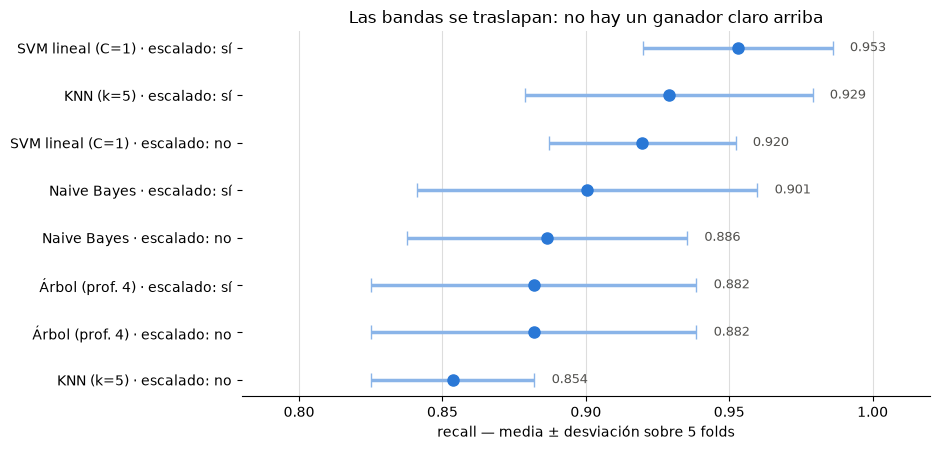

In [8]:
orden = sorted(crudo.items(), key=lambda kv: kv[1].mean())
etiquetas = [f"{n} · escalado: {e}" for (n, e), _ in orden]
medias = [v.mean() for _, v in orden]
desvs  = [v.std()  for _, v in orden]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
pos = np.arange(len(orden))
ax.errorbar(medias, pos, xerr=desvs, fmt="o", markersize=8, capsize=5,
            color="#2a78d6", ecolor="#8ab4e8", elinewidth=2.5)
ax.set_yticks(pos); ax.set_yticklabels(etiquetas)
ax.set_xlabel("recall — media ± desviación sobre 5 folds")
ax.set_title("Las bandas se traslapan: no hay un ganador claro arriba")
ax.grid(axis="x", color="#dddddd", linewidth=.8); ax.set_axisbelow(True)
for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)
for p, m_, d in zip(pos, medias, desvs):
    ax.text(m_ + d + .006, p, f"{m_:.3f}", va="center", fontsize=9, color="#52514e")
ax.set_xlim(.78, 1.02)
plt.tight_layout(); plt.show()

### Cómo se lee

| | Lo que dice |
|---|---|
| **Qué veo** | Escalar sube el recall del **KNN de 0,854 a 0,929** y el del **SVM de 0,920 a 0,953**. En el **árbol las dos filas son idénticas hasta el tercer decimal** en las cuatro métricas. Naive Bayes casi no se mueve (0,886 → 0,901). |
| **Qué significa** | Lo que ya sabíamos, ahora medido con dispersión: **los modelos que usan distancias necesitan escalado**; el árbol parte por umbrales de una variable a la vez y un cambio de escala no cambia el orden de los datos, así que le da igual. |
| **Qué decido** | KNN y SVM **siempre** con `StandardScaler` adentro del `Pipeline`. En el árbol se puede reportar una sola fila, con la nota de que se verificó que no cambia. |

**Frase de negocio (la que va en la entrega):** *«De cada 100 tumores malignos, el SVM lineal escalado
detecta 95 y deja pasar 5; el árbol podado detecta 88 y deja pasar 12. Sobre los 212 malignos del
estudio, eso son unos 15 cánceres de diferencia.»*

> Naive Bayes en teoría tampoco debería depender del escalado —trata cada variable por separado—.
> La diferencia pequeña que se ve viene del suavizado de varianza que scikit-learn aplica por dentro,
> que sí depende de la escala. Es un detalle, no una lección.

# 4. Escoger hiperparámetros sin gastar el conjunto de prueba

Ayer probamos C = 0,01 · 0,1 · 1 · 10 · 100 **mirando el conjunto de prueba** y escogimos el mejor.
Eso está mal, y hay que decirlo con todas las letras: **si escojo el hiperparámetro mirando la prueba,
la prueba ya no es prueba.** Se volvió parte del entrenamiento, y el número que reporto está inflado.

La forma correcta:

1. Se aparta el conjunto de prueba **y se guarda**.
2. **Dentro del entrenamiento** se hace validación cruzada para escoger los hiperparámetros
   (`GridSearchCV` prueba todas las combinaciones y se queda con la mejor).
3. Se entrena el ganador con todo el entrenamiento.
4. **Se mide una sola vez en la prueba** y ese es el número que se reporta.

In [9]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.3, random_state=7, stratify=y)
print("entrenamiento:", len(ytr), "| prueba:", len(yte), "| malignos en prueba:", yte.sum())

rejillas = {
 "Árbol":      (Pipeline([("modelo", DecisionTreeClassifier(random_state=7))]),
                {"modelo__max_depth": [2, 3, 4, 6, None]}),
 "KNN":        (Pipeline([("escalador", StandardScaler()), ("modelo", KNeighborsClassifier())]),
                {"modelo__n_neighbors": [1, 3, 5, 9, 15, 25]}),
 "SVM lineal": (Pipeline([("escalador", StandardScaler()), ("modelo", SVC(kernel="linear"))]),
                {"modelo__C": [0.01, 0.1, 1, 10, 100]}),
}

ganadores = {}
for nombre, (pipe, rejilla) in rejillas.items():
    gs = GridSearchCV(pipe, rejilla, cv=cv, scoring="recall").fit(Xtr, ytr)
    ganadores[nombre] = gs
    valores = [(list(p.values())[0], round(s, 3))
               for p, s in zip(gs.cv_results_["params"], gs.cv_results_["mean_test_score"])]
    print(f"\n{nombre}")
    print("  todo lo que probó:", valores)
    print("  escoge:", gs.best_params_, "con recall CV", round(gs.best_score_, 3))

entrenamiento: 398 | prueba: 171 | malignos en prueba: 64



Árbol
  todo lo que probó: [(2, np.float64(0.905)), (3, np.float64(0.932)), (4, np.float64(0.925)), (6, np.float64(0.919)), (None, np.float64(0.919))]
  escoge: {'modelo__max_depth': 3} con recall CV 0.932



KNN
  todo lo que probó: [(1, np.float64(0.912)), (3, np.float64(0.932)), (5, np.float64(0.932)), (9, np.float64(0.919)), (15, np.float64(0.891)), (25, np.float64(0.885))]
  escoge: {'modelo__n_neighbors': 5} con recall CV 0.932



SVM lineal
  todo lo que probó: [(0.01, np.float64(0.912)), (0.1, np.float64(0.973)), (1, np.float64(0.966)), (10, np.float64(0.932)), (100, np.float64(0.952))]
  escoge: {'modelo__C': 0.1} con recall CV 0.973


In [10]:
print("EL CONJUNTO DE PRUEBA, UNA SOLA VEZ\n")
filas = []
for nombre, gs in ganadores.items():
    p = gs.predict(Xte)
    vn, fp, fn, vp = confusion_matrix(yte, p).ravel()
    filas.append({"modelo": nombre,
                  "hiperparámetro": str(gs.best_params_).split("__")[1].rstrip("}").replace("'", ""),
                  "exactitud": round(accuracy_score(yte, p), 3),
                  "precisión": round(precision_score(yte, p), 3),
                  "recall": round(recall_score(yte, p), 3),
                  "F1": round(f1_score(yte, p), 3),
                  "detecta": f"{vp} de {vp + fn}",
                  "falsas alarmas": fp})
print(pd.DataFrame(filas).to_string(index=False))

EL CONJUNTO DE PRUEBA, UNA SOLA VEZ

    modelo hiperparámetro  exactitud  precisión  recall    F1  detecta  falsas alarmas
     Árbol   max_depth: 3      0.906      0.875   0.875 0.875 56 de 64               8
       KNN n_neighbors: 5      0.971      0.984   0.938 0.960 60 de 64               1
SVM lineal         C: 0.1      0.971      0.984   0.938 0.960 60 de 64               1


### Cómo se lee

| | Lo que dice |
|---|---|
| **Qué veo** | La búsqueda escoge profundidad 3 para el árbol, k = 5 para KNN y **C = 0,1** para el SVM —no el C = 10 que ayer parecía el mejor mirando la prueba—. Y en la prueba, tocada una sola vez, **KNN y SVM dan el resultado idéntico otra vez: 60 de 64 malignos, 1 falsa alarma, F1 = 0,960**. |
| **Qué significa** | Dos rutas distintas llegan al mismo punto. La validación cruzada decía que el SVM iba adelante (0,973 contra 0,932 de recall en CV), y aun así en la prueba empatan: **la ventaja era más pequeña que el ruido de una partición**. |
| **Qué decido** | Ese empate **no se rompe con más decimales**. Se rompe con un criterio que no es la métrica: costo, velocidad o capacidad de explicar la decisión. |

> **La regla, que va en el informe:** el conjunto de prueba se toca **una sola vez**, al final. Si lo
> miran, ajustan y vuelven a mirar, el número que reportan ya no mide nada.

# 5. Cómo se decide el ganador

**Tres reglas, en este orden.**

### Regla 1 — La métrica se escoge ANTES de mirar la tabla

Se escoge por el **costo de cada error**, no por cuál da más bonito:

| Si el error caro es… | Manda | Ejemplo |
|---|---|---|
| Dejar pasar un positivo (falso negativo) | **recall** | Cáncer no detectado, fraude que pasa, deserción que no se previene |
| Alarmar de más (falso positivo) | **precisión** | Bloquear la tarjeta a un cliente honesto, marcar spam un correo bueno |
| Los dos importan parecido | **F1** | Comparación general sin un costo claro |
| Las clases están equilibradas y ningún error es peor | exactitud | Casi nunca en problemas reales |

Escribirla **antes** es lo que impide el autoengaño de salir a buscar la métrica donde mi modelo
favorito gana.

### Regla 2 — Si las bandas se traslapan, NO hay ganador

Dos modelos con 0,953 ± 0,033 y 0,929 ± 0,050 **no están separados**: sus rangos comparten casi todo.
Decir «el SVM es mejor» ahí es leer ruido. Es la misma frase de siempre: **diferencia no es
separación**.

### Regla 3 — Empatados, gana el más simple o el más explicable

Cuando no hay diferencia medible, se desempata con lo demás:

- **¿Hay que explicarle la decisión a una persona?** Un árbol se lee como reglas; un SVM, no. En un
  banco o un hospital eso vale más que un punto de F1.
- **¿Cuántos datos tiene que cargar para predecir?** El KNN guarda todo el dataset; el SVM solo los
  vectores de soporte; el árbol, unas reglas.
- **¿Cuánto tarda en entrenar y en predecir?** Con muchas filas el KNN y el SVM se vuelven lentos.

> **En este problema**, con el recall escogido de antemano: SVM lineal escalado y KNN escalado están
> empatados. Si el hospital necesita justificar cada diagnóstico, se va el árbol aunque deje pasar más
> cánceres — y esa decisión se **escribe**, con su costo al lado. **No hay mejor modelo en abstracto;
> hay uno mejor para un costo de error y una necesidad de explicar.**

# 6. Actividad práctica — la tabla de la entrega, sobre su dataset (45 minutos)

**Esto es la entrega del miércoles 23.** Lo que salga de aquí se pega en el informe.

Cada grupo trabaja sobre **su propio dataset**. Para subirlo a Colab hay dos formas:

```python
# Opción A — subir el archivo desde el computador (se borra al cerrar la sesión)
from google.colab import files
subidos = files.upload()                      # abre el selector de archivos
import pandas as pd
misdatos = pd.read_csv(next(iter(subidos)))

# Opción B — desde Google Drive (queda guardado)
from google.colab import drive
drive.mount('/content/drive')
misdatos = pd.read_csv('/content/drive/MyDrive/mineria/mi_dataset.csv')
```

Después, **solo hay que cambiar las tres primeras líneas de la celda de abajo.** El resto ya funciona.

## Lista de chequeo

Marquen cada punto antes de cerrar el portátil:

- [ ] **1.** `X` y `y` armados, con `y` **binaria** (0/1) y la **clase positiva definida**: la que
      cuesta no detectar.
- [ ] **2.** Escrita la proporción de la clase positiva. Si es menor al 10 %, **la exactitud no sirve**
      y hay que decirlo en el informe.
- [ ] **3.** Escrita **la métrica que manda y por qué** — antes de correr nada. Una frase con el costo
      del error.
- [ ] **4.** Los cuatro modelos corridos **con y sin escalar** (8 filas), todos dentro de `Pipeline`.
- [ ] **5.** Validación cruzada **estratificada** con k = 5 y la tabla en formato **media ± desviación**.
- [ ] **6.** Verificado que en su dataset **el árbol también da igual con y sin escalar**, y que KNN y
      SVM sí cambian. Si no pasa, revisen si las variables ya venían en escalas parecidas.
- [ ] **7.** `GridSearchCV` corrido para **al menos un** hiperparámetro (k, profundidad o C), **sobre el
      entrenamiento**, nunca sobre la prueba.
- [ ] **8.** Revisado si las bandas **se traslapan**. Si se traslapan, en el informe va escrito
      «no hay diferencia medible» y el desempate por simplicidad o explicabilidad.
- [ ] **9.** La **frase de negocio**: «de cada 100 ___, el modelo detecta ___ y deja pasar ___».
- [ ] **10.** El notebook **corre de arriba abajo sin errores** y con las salidas guardadas.

In [11]:
# ============================================================
#  PLANTILLA DE LA ENTREGA — cambien SOLO estas tres líneas
# ============================================================
mis_datos      = X.copy()          # <- su DataFrame
mi_objetivo    = y.copy()          # <- su columna objetivo, binaria 0/1
metrica_manda  = "recall"          # <- "recall", "precision", "f1" o "accuracy"
# ============================================================

print("filas:", len(mi_objetivo),
      "| clase positiva:", mi_objetivo.sum(),
      f"({mi_objetivo.mean():.1%})",
      "| métrica que manda:", metrica_manda)
if mi_objetivo.mean() < .10:
    print(">> OJO: clase positiva por debajo del 10 % — la exactitud NO sirve acá.")

cv_g = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
mis_modelos = {"Árbol (prof. 4)":  DecisionTreeClassifier(max_depth=4, random_state=7),
               "KNN (k=5)":        KNeighborsClassifier(),
               "Naive Bayes":      GaussianNB(),
               "SVM lineal (C=1)": SVC(kernel="linear")}

filas = []
for nombre, m in mis_modelos.items():
    for escalado in [False, True]:
        pasos = [("escalador", StandardScaler())] if escalado else []
        r = cross_validate(Pipeline(pasos + [("modelo", m)]), mis_datos, mi_objetivo,
                           cv=cv_g, scoring=["accuracy", "precision", "recall", "f1"])
        fila = {"modelo": nombre, "escalado": "sí" if escalado else "no"}
        for k in ["accuracy", "precision", "recall", "f1"]:
            fila[nombres_es[k]] = f"{r['test_' + k].mean():.3f} ± {r['test_' + k].std():.3f}"
        filas.append(fila)

mi_tabla = pd.DataFrame(filas)
print()
print(mi_tabla.to_string(index=False))
print("\nOrdenados por", metrica_manda, "— el de arriba es el candidato, NO el ganador:")
clave = {"recall": "recall", "precision": "precisión", "f1": "F1", "accuracy": "exactitud"}[metrica_manda]
print(mi_tabla.assign(_m=mi_tabla[clave].str.split(" ± ").str[0].astype(float))
              .sort_values("_m", ascending=False)[["modelo", "escalado", clave]]
              .to_string(index=False))

filas: 569 | clase positiva: 212 (37.3%) | métrica que manda: recall



          modelo escalado     exactitud     precisión        recall            F1
 Árbol (prof. 4)       no 0.926 ± 0.038 0.920 ± 0.066 0.882 ± 0.057 0.899 ± 0.052
 Árbol (prof. 4)       sí 0.926 ± 0.038 0.920 ± 0.066 0.882 ± 0.057 0.899 ± 0.052
       KNN (k=5)       no 0.921 ± 0.017 0.931 ± 0.049 0.854 ± 0.028 0.890 ± 0.022
       KNN (k=5)       sí 0.968 ± 0.022 0.985 ± 0.020 0.929 ± 0.050 0.956 ± 0.032
     Naive Bayes       no 0.935 ± 0.027 0.937 ± 0.044 0.886 ± 0.049 0.910 ± 0.038
     Naive Bayes       sí 0.932 ± 0.031 0.913 ± 0.034 0.901 ± 0.059 0.906 ± 0.044
SVM lineal (C=1)       no 0.953 ± 0.018 0.956 ± 0.055 0.920 ± 0.033 0.936 ± 0.023
SVM lineal (C=1)       sí 0.970 ± 0.014 0.967 ± 0.024 0.953 ± 0.033 0.959 ± 0.020

Ordenados por recall — el de arriba es el candidato, NO el ganador:
          modelo escalado        recall
SVM lineal (C=1)       sí 0.953 ± 0.033
       KNN (k=5)       sí 0.929 ± 0.050
SVM lineal (C=1)       no 0.920 ± 0.033
     Naive Bayes       sí 0.901 

In [12]:
# Búsqueda de hiperparámetros sobre SU dataset (punto 7 de la lista)
Xtr_g, Xte_g, ytr_g, yte_g = train_test_split(mis_datos, mi_objetivo, test_size=.3,
                                              random_state=7, stratify=mi_objetivo)

mis_rejillas = {
 "Árbol":      (Pipeline([("modelo", DecisionTreeClassifier(random_state=7))]),
                {"modelo__max_depth": [2, 3, 4, 6, None]}),
 "KNN":        (Pipeline([("escalador", StandardScaler()), ("modelo", KNeighborsClassifier())]),
                {"modelo__n_neighbors": [1, 3, 5, 9, 15, 25]}),
 "SVM lineal": (Pipeline([("escalador", StandardScaler()), ("modelo", SVC(kernel="linear"))]),
                {"modelo__C": [0.01, 0.1, 1, 10, 100]}),
}

for nombre, (pipe, rejilla) in mis_rejillas.items():
    gs = GridSearchCV(pipe, rejilla, cv=cv_g, scoring=metrica_manda).fit(Xtr_g, ytr_g)
    print(f"{nombre:<11} escoge {str(gs.best_params_):<35} "
          f"{metrica_manda} CV {gs.best_score_:.3f}")

print("\nLa prueba se toca UNA sola vez, cuando ya escogieron el modelo definitivo.")

Árbol       escoge {'modelo__max_depth': 3}            recall CV 0.932


KNN         escoge {'modelo__n_neighbors': 5}          recall CV 0.932


SVM lineal  escoge {'modelo__C': 0.1}                  recall CV 0.973

La prueba se toca UNA sola vez, cuando ya escogieron el modelo definitivo.


# Preguntas conceptuales

1. Un compañero reporta «mi SVM da 0,98 de recall». ¿Qué **dos** preguntas hay que hacerle antes de
   creerle?
2. ¿Por qué la validación cruzada **estratificada** importa más cuando la clase positiva es rara?
3. Un modelo da 0,90 ± 0,02 y otro 0,93 ± 0,06. ¿Cuál escogen y por qué?
4. Si `GridSearchCV` escoge los hiperparámetros con validación cruzada **sobre el entrenamiento**,
   ¿para qué sirve entonces el conjunto de prueba?
5. ¿Por qué escalar **dentro** del `Pipeline` y no antes, si en este dataset dio exactamente lo mismo?
6. En la tabla final, el árbol da idéntico con y sin escalar. ¿Qué tiene el árbol que KNN y SVM no
   tienen?

# Conclusión

| | |
|---|---|
| **Una partición** | Es una muestra del azar: puede coronar a cuatro ganadores distintos |
| **Validación cruzada** | k folds estratificados; se reporta **media ± desviación**, nunca la media sola |
| **La dispersión** | Es la confianza que le tengo al número, y es lo que decide si hay ganador |
| **`Pipeline`** | Todo el preprocesamiento adentro: la fuga no avisa cuando ocurre |
| **`GridSearchCV`** | Los hiperparámetros salen del entrenamiento; **la prueba se toca una sola vez** |
| **El ganador** | Métrica escogida antes · bandas que no se traslapan · empate → el más simple o el más explicable |

# Próxima clase y fechas del corte 1

| Cuándo | Qué |
|---|---|
| **Miércoles 23 de septiembre, 11:59 p. m.** | **Entrega del producto del corte 1**: la tabla modelo × escalado con media ± desviación, la métrica justificada de antemano, la decisión escrita y la frase de negocio |
| **Jueves 24 de septiembre, 8–10 a. m.** | **Quiz del corte 1**: árboles, KNN, Naive Bayes, SVM, métricas y validación cruzada |
| **Sábado 26 de septiembre** | **Sustentación** por grupos: cada uno defiende su tabla y su decisión |

# Referencias

- Han, J., Kamber, M. y Pei, J. *Data Mining: Concepts and Techniques*. Morgan Kaufmann. Capítulo de
  evaluación y selección de modelos.
- Hastie, T., Tibshirani, R. y Friedman, J. *The Elements of Statistical Learning*. Springer.
  Capítulo 7: evaluación y selección de modelos.
- Documentación de scikit-learn: *Cross-validation: evaluating estimator performance* y
  *Tuning the hyper-parameters of an estimator*.
- Wolberg, W., Street, W. y Mangasarian, O. *Breast Cancer Wisconsin (Diagnostic)*. UCI Machine
  Learning Repository.

---

*Minería de Datos · 26150 · periodo 2026-3 · Jhon Alejandro Varón Robayo · Universidad Distrital Francisco José de Caldas.*